### **Linear regression from Scratch part II**

## **Gradient Descent from Scratch:**

**Gradient Descent :** gradient descent is a mathematical technique that iteratively finds the best values of weights and bias. By repeating the following process.

- The model begins training with randomized weights and bias near zero and then represents the following process.
1. Calculate the loss with the current weight and bias.
2. Determine the direction to move the weights and bias that reduce loss.
3. Move the weights and bias values a small amount in the direction that reduce loss.
4. Return to step one and repeat the process until the model can't reduce loss any further.



**Formula :**

For Simple Linear Regression (y = mx + b), gradient descent updates weights and bias using these formulas:

**Gradient for weight (m):**

dm = (2/n) * Σ (y_pred - y_actual) * X

**Gradient for bias (b):**

db = (2/n) * Σ (y_pred - y_actual)

**Update Rules:**

m = m - α * dm

b = b - α * db

Where:
- α (alpha) = Learning rate
- n = Number of data points
- y_pred = Predicted value (mX + b)
- y_actual = Actual value
- dm = Gradient for weight
- db = Gradient for bias



### **Hyperparameters :**
Hyperparameters are variables that control different aspects of training. Three common hyperparameters are:
- Learning rate (alpha)
- Batch size
- Epochs

**1. Learning Rate :** (alpha) It's a hyperparameter and it controls how big of a step we take in each gradient descent iteration.
1. Too Small alpha : very slow, can take long time to converge.
2. Too High alpha : Might overshoot and never converge.
3. We need just the right alpha - not too small and not too high.
4. Common ranges of alpha : 0.001 to 0.1.

**2. Batch Size :** Batch size is a hyperparameter that refers to the number of examples the model processes before updating its weight and bias. We might think that the model should calculate the loss of every example in the dataset before updating its weight and bias. However, when the dataset contains hundreds of thousands or even millions of examples, using full batch is not practical.

> There are two common techniques to get the right gradient average without needing to look at every example in the dataset before updating the weight and bias:

1. Stochastic Gradient Descent (SGD)
2. Mini-Batch Stochastic Gradient Descent

**1. Stochastic Gradient Descent :** (SGD) uses only a single example (batch size of one) per iteration. Given enough iterations, SGD works perfectly. But it's very noisy. **NOISE** refers to variations during the training that cause the loss to increase rather than decrease during an iteration. The term **STOCHASTIC** indicates that the one example comprising each batch is chosen at random.

**2. Mini-Batch Stochastic Gradient Descent :** is a compromise between full batch size and SGD. For n number of data points, the batch size can be any number greater than 1 and less than n. The model chooses the examples included in each batch at random, averages their gradients, and then updates the weights and bias once per iteration.

**3. Epochs :** An epoch is one complete pass through the entire training dataset. It means the model has seen every example in the dataset exactly once. Epochs are a hyperparameter that controls how many times the model will iterate over the full dataset.

- **1 Epoch** = Model sees all data once
- **10 Epochs** = Model sees all data 10 times
- **Too Few Epochs** = Model underfits (doesn't learn enough)
- **Too Many Epochs** = Model overfits (memorizes data instead of learning patterns)
- **Common ranges** = 10 to 1000 epochs depending on dataset size

The training stops when either:
1. The maximum number of epochs is reached, or
2. The loss stops decreasing (convergence)


### **Loss History**

Loss history is a record of the loss value at every iteration (or epoch) during training. It is stored in a list and used to:

1. **Track Training Progress** - See how the loss decreases over time
2. **Detect Convergence** - Identify when the model has stopped improving
3. **Diagnose Problems** - Spot overfitting or underfitting early
4. **Tune Hyperparameters** - Compare different learning rates and batch sizes
5. **Visualize Learning** - Plot loss vs iterations to understand training behavior

**Example:**
```python
loss_history = []   # Empty list to store loss values

for i in range(epochs):
    y_pred = m * X + b
    error = y_pred - Y
    loss = (error ** 2).mean()
    loss_history.append(loss)   # Store loss each iteration
    
    # Update weights and bias
    m -= lr * dm
    b -= lr * db

### Hands on Gradient Descent:
#### Step 1: imports artifacts and Build Fake Datset

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

data={
    "X":[1,2,3,4,5,6,7,8],
    "Y":[89,74,67,80,89,70,69,79]
}
df=pd.DataFrame(data)
X=df["X"].values
Y=df["Y"].values
df

,X,Y
0,1,89
1,2,74
2,3,67
3,4,80
4,5,89
5,6,70
6,7,69
7,8,79


#### Step 2: Defining parameters

In [2]:
m=0        # weight
b=0        # Bias
lr=0.01    # alpha
loss_history=[]   # loss history
print("Done")

Done


#### Step 3: Calculate error and Gradient

In [3]:
for i in range(50):
    y_pred=m*X+b
    error=y_pred-Y
    loss=(error**2).mean()
    loss_history.append(loss)
    n=len(df)
    dm=(2/n)*np.sum(error*X)
    db=(2/n)*np.sum(error)
    m -= lr*dm
    b -= lr*db
    print(f"step {i} : loss :{loss:.2f} , m :{m:.2f} and b :{b:.2f}")


step 0 : loss :6013.62 , m :6.84 and b :1.54
step 1 : loss :2382.47 , m :10.06 and b :2.44
step 2 : loss :1558.83 , m :11.56 and b :3.03
step 3 : loss :1366.00 , m :12.23 and b :3.47
step 4 : loss :1314.96 , m :12.53 and b :3.84
step 5 : loss :1295.83 , m :12.64 and b :4.18
step 6 : loss :1283.94 , m :12.66 and b :4.50
step 7 : loss :1273.74 , m :12.64 and b :4.81
step 8 : loss :1263.97 , m :12.61 and b :5.12
step 9 : loss :1254.36 , m :12.56 and b :5.43
step 10 : loss :1244.84 , m :12.51 and b :5.73
step 11 : loss :1235.41 , m :12.46 and b :6.03
step 12 : loss :1226.05 , m :12.41 and b :6.33
step 13 : loss :1216.76 , m :12.35 and b :6.63
step 14 : loss :1207.55 , m :12.30 and b :6.93
step 15 : loss :1198.42 , m :12.25 and b :7.23
step 16 : loss :1189.35 , m :12.20 and b :7.52
step 17 : loss :1180.36 , m :12.14 and b :7.82
step 18 : loss :1171.44 , m :12.09 and b :8.11
step 19 : loss :1162.59 , m :12.04 and b :8.40
step 20 : loss :1153.81 , m :11.99 and b :8.69
step 21 : loss :1145.10 

#### Step 4: Visualise the loss history.

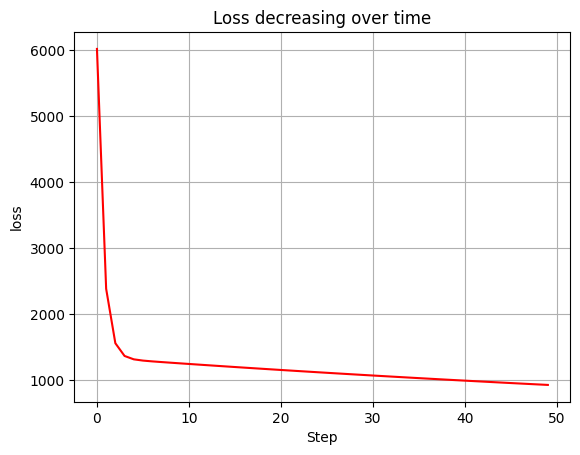

In [4]:
plt.plot(loss_history,color='red')
plt.title("Loss decreasing over time")
plt.xlabel("Step")
plt.ylabel("loss")
plt.grid(True)

#### Step 5: Final prediction

In [5]:
y_pred_final=m*X+b
final_error=y_pred_final-Y
MAE=np.abs(final_error).mean()
MSE=(final_error**2).mean()
print("MAE :",round(MAE,2))
print("MSE :",round(MSE,2))

MAE : 26.4
MSE : 920.61


### Step 6: Final Visualisation

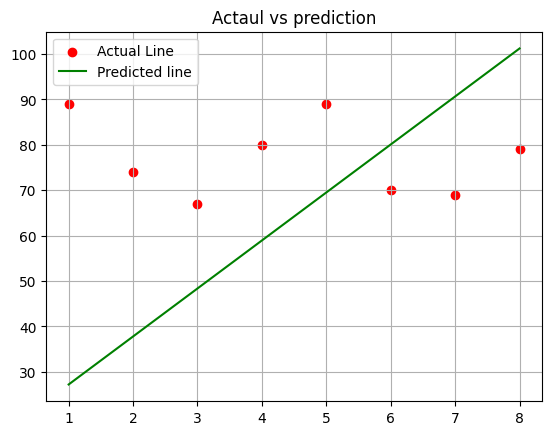

In [6]:
plt.scatter(X,Y,label="Actual Line",color="red")
plt.plot(X,y_pred_final,label="Predicted line",color="green")
plt.title("Actaul vs prediction")
plt.legend()
plt.grid(True)


## KHTAM (Part II)

Gradient Descent from scratch completed with theory and implementation:
- Gradient descent formula (dm, db) and update rules
- Hyperparameters: Learning rate, Batch size, Epochs
- Loss history tracking and visualization
- 50 iterations of gradient descent

### Note on Current Model
The current model is not fully optimized yet. Loss is still decreasing at step 50, which means more iterations and proper hyperparameter tuning are needed.

### Next (Part III):
- Hyperparameter tuning (learning rate, epochs)
- Learning rate comparison (0.001, 0.01, 0.1, 1.0)
- Epochs comparison
- Convergence detection
- Optimized model building

---
End of Linear Regression - Part II